<div style="border-radius:10px;border:#015a2c solid;background-color:#D7D9DB;font-size:110%;letter-spacing:0.5px;text-align:center">
<h1 style="padding:25px 0;color:#015a4c;font-weight:bold">Final Project – Data Science Module</h1>
<h3 style="padding-bottom:25px;color:#025b2c;font-style:italic">Dataset Exploration for Ford GoBike – February 2019</h3>
</div>

# Part I – Dataset Exploration for Ford GoBike

## Introduction
This project explores the provided **Ford GoBike trip dataset for February 2019**. The dataset contains individual bike-sharing trips from the San Francisco Bay Area system. Each record includes trip duration, station information, user type, demographic attributes, and whether the rider used the Bike Share for All program.

### Main questions
The analysis focuses on the following themes:
- What is the structure and quality of the dataset?
- What are the distributions of user type, age, gender, Bike Share for All usage, and trip duration?
- How does trip duration vary by user type and gender?
- How does rider age vary across user types and gender groups?
- Which numeric variables are correlated with one another?

The project follows: **Preliminary Wrangling → Data Assessment → Data Cleaning → Univariate EDA → Bivariate EDA → Multivariate EDA → Conclusions and Recommendations**.

## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

ModuleNotFoundError: No module named 'matplotlib'

# Preliminary Wrangling

In [ ]:
# Load the dataset. The fallback path is included so this notebook also runs in this environment.
csv_path = 'fordgobike-tripdataFor201902.csv'
if not os.path.exists(csv_path):
    csv_path = '/mnt/data/fordgobike-tripdataFor201902.csv'

gbf_raw = pd.read_csv(csv_path)
gbf = gbf_raw.copy()
print(f"Dataset shape: {gbf.shape[0]:,} rows × {gbf.shape[1]} columns")
gbf.head()

Dataset shape: 183,416 rows × 16 columns


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [ ]:
# High-level overview
gbf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  object 
 2   end_time                 183416 non-null  object 
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  object 
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  object 
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  object 
 13  member_birth_year        175151 non-null  float64
 14  memb

In [ ]:
# Display a sample of rows to understand the content
gbf.head(15)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [ ]:
# Descriptive statistics for numeric variables
gbf.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_sec,183416.0,726.067311,1794.371831,61.000000,325.000000,514.000000,796.000000,85444.000000
start_station_id,183219.0,138.590365,111.778938,3.000000,47.000000,104.000000,239.000000,398.000000
start_station_latitude,183416.0,37.771221,0.099586,37.317298,37.770083,37.780760,37.797280,37.880222
start_station_longitude,183416.0,-122.352661,0.117100,-122.453705,-122.412408,-122.398285,-122.286533,-121.874119
end_station_id,183219.0,136.249401,111.514916,3.000000,44.000000,100.000000,235.000000,398.000000
end_station_latitude,183416.0,37.771425,0.099494,37.317298,37.770407,37.781010,37.797320,37.880222
end_station_longitude,183416.0,-122.352247,0.116677,-122.453705,-122.411726,-122.398279,-122.288045,-121.874119
bike_id,183416.0,4472.890260,1664.386068,11.000000,3777.000000,4958.000000,5502.000000,6645.000000
member_birth_year,175151.0,1984.806504,10.116589,1878.000000,1980.000000,1987.000000,1992.000000,2001.000000


### Structure of the dataset
The raw dataset contains **183,416 rows and 16 columns**. Numeric columns include trip duration, station coordinates/IDs, bike ID, and birth year. Categorical/text columns include station names, user type, gender, Bike Share for All status, and the two time columns.

### Main features of interest
1. **Trip behavior:** `duration_sec` and derived duration in minutes/hours.
2. **Rider characteristics:** `user_type`, `member_birth_year`, `member_gender`, and derived age.
3. **Program usage:** `bike_share_for_all_trip`.

Station coordinates and IDs provide geographic context, although detailed geographic routing is outside the scope of this project.

# Data Assessment

In [ ]:
# Missing values
missing = gbf.isna().sum().to_frame('missing_count')
missing['missing_percent'] = (missing['missing_count'] / len(gbf) * 100).round(2)
missing[missing['missing_count'] > 0]

,missing_count,missing_percent
start_station_id,197,0.11
start_station_name,197,0.11
end_station_id,197,0.11
end_station_name,197,0.11
member_birth_year,8265,4.51
member_gender,8265,4.51


In [ ]:
# Duplicate rows
duplicate_count = gbf.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count}")

Exact duplicate rows: 4


In [ ]:
# Inspect categorical values
for col in ['user_type', 'member_gender', 'bike_share_for_all_trip']:
    print()
    print(f'{col}:')
    print(gbf[col].value_counts(dropna=False))


user_type:
user_type
Subscriber    163548
Customer       19868
Name: count, dtype: int64

member_gender:
member_gender
Male      130655
Female     40844
NaN         8265
Other       3652
Name: count, dtype: int64

bike_share_for_all_trip:
bike_share_for_all_trip
No     166056
Yes     17360
Name: count, dtype: int64


In [ ]:
# Check extreme numeric values
assessment_summary = pd.DataFrame({
    'member_birth_year': gbf['member_birth_year'].describe(),
    'duration_sec': gbf['duration_sec'].describe()
})
assessment_summary

,member_birth_year,duration_sec
count,175151.000000,183416.000000
mean,1984.806504,726.067311
std,10.116589,1794.371831
min,1878.000000,61.000000
25%,1980.000000,325.000000
50%,1987.000000,514.000000
75%,1992.000000,796.000000
max,2001.000000,85444.000000


In [ ]:
# Inspect the time-format issue in the provided file
gbf[['start_time', 'end_time']].head(10)

,start_time,end_time
0,32:10.1,01:56.0
1,53:21.8,42:03.1
2,13:13.2,24:08.1
3,54:26.0,02:36.8
4,54:18.5,20:44.1
5,49:58.6,19:51.8
6,55:35.1,14:42.6
7,41:06.8,08:02.8
8,41:48.8,07:59.7
9,49:47.7,07:17.0


### Data quality issues identified
- `start_station_id`, `start_station_name`, `end_station_id`, and `end_station_name` each have **197 missing values**.
- `member_birth_year` and `member_gender` each have **8,265 missing values**.
- There are **4 exact duplicate rows**.
- `member_birth_year` reaches as far back as **1878**, which would imply an age of 141 in 2019. These are implausible demographic records and need treatment.
- Trip duration is strongly right-skewed. The maximum is **85,444 seconds (~23.7 hours)**. This is extreme but not automatically impossible, so it will be retained and handled with restricted plot ranges when needed.
- In the provided CSV, `start_time` and `end_time` appear only as strings such as `32:10.1`, rather than complete date-time stamps. Therefore, day-of-week and hour-of-day analysis cannot be performed reliably from this file and these columns will remain text.
- `user_type`, `member_gender`, and `bike_share_for_all_trip` are stored as `object`; they are better represented as categorical variables.

# Data Cleaning

In [ ]:
# 1) Remove exact duplicates
gbf = gbf.drop_duplicates().copy()

# 2) Drop rows missing critical station or demographic information
critical_cols = [
    'start_station_id', 'start_station_name', 'end_station_id', 'end_station_name',
    'member_birth_year', 'member_gender'
]
gbf = gbf.dropna(subset=critical_cols).copy()

print(f"Shape after duplicates and missing-value removal: {gbf.shape}")

Shape after duplicates and missing-value removal: (174952, 16)


In [ ]:
# 3) Correct data types
gbf['start_station_id'] = gbf['start_station_id'].astype(int)
gbf['end_station_id'] = gbf['end_station_id'].astype(int)
gbf['member_birth_year'] = gbf['member_birth_year'].astype(int)

for col in ['user_type', 'member_gender', 'bike_share_for_all_trip']:
    gbf[col] = gbf[col].astype('category')

gbf.dtypes

duration_sec                  int64
start_time                   object
end_time                     object
start_station_id              int64
start_station_name           object
start_station_latitude      float64
start_station_longitude     float64
end_station_id                int64
end_station_name             object
end_station_latitude        float64
end_station_longitude       float64
bike_id                       int64
user_type                  category
member_birth_year             int64
member_gender              category
bike_share_for_all_trip    category
dtype: object

In [ ]:
# 4) Create rider age using the dataset year (2019)
gbf['member_age'] = 2019 - gbf['member_birth_year']

# Inspect implausible ages before filtering
print(gbf['member_age'].describe())
print(f"Rows with age > 80: {(gbf['member_age'] > 80).sum()}")

count    174952.000000
mean         34.196865
std          10.118731
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max         141.000000
Name: member_age, dtype: float64
Rows with age > 80: 192


In [ ]:
# Remove implausible age records (> 80 years).
# This affects only a very small fraction of the otherwise complete records.
gbf = gbf[gbf['member_age'].between(18, 80)].copy()
gbf['member_age'] = gbf['member_age'].astype(int)

In [ ]:
# 5) Create easier-to-interpret trip-duration measures
gbf['duration_min'] = gbf['duration_sec'] / 60
gbf['duration_hour'] = gbf['duration_sec'] / 3600

# Final quality checks
print(f"Final cleaned shape: {gbf.shape[0]:,} rows × {gbf.shape[1]} columns")
print(f"Remaining missing values: {gbf.isna().sum().sum()}")
print(f"Remaining duplicate rows: {gbf.duplicated().sum()}")
gbf[['member_age', 'duration_sec', 'duration_min', 'duration_hour']].describe().T

Final cleaned shape: 174,760 rows × 19 columns


Remaining missing values: 0


Remaining duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
member_age,174760.0,34.125223,9.877739,18.000000,27.000000,32.000000,39.000000,80.000000
duration_sec,174760.0,704.309630,1643.031657,61.000000,323.000000,511.000000,789.000000,84548.000000
duration_min,174760.0,11.738494,27.383861,1.016667,5.383333,8.516667,13.150000,1409.133333
duration_hour,174760.0,0.195642,0.456398,0.016944,0.089722,0.141944,0.219167,23.485556


### Cleaning result
The final analytical dataset contains **174,760 rows**. Exact duplicates, rows with missing critical demographic/station information, and implausible ages above 80 were removed. Category data types and derived variables (`member_age`, `duration_min`, `duration_hour`) were added.

# Univariate Exploration

## 1) What is the distribution of User Type?

             count  percent
user_type                  
Subscriber  158203    90.53
Customer     16557     9.47


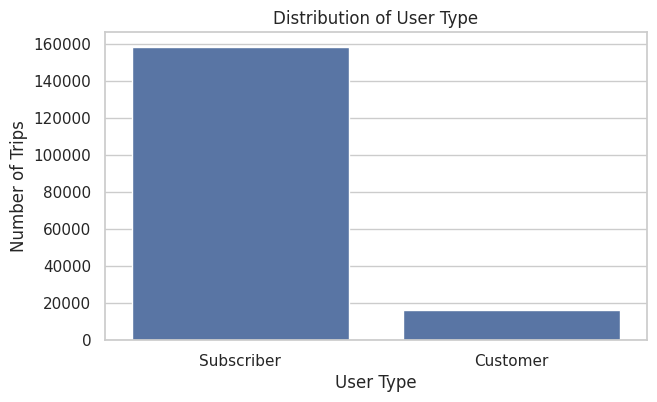

In [ ]:
user_counts = gbf['user_type'].value_counts()
user_pct = (gbf['user_type'].value_counts(normalize=True) * 100).round(2)
print(pd.DataFrame({'count': user_counts, 'percent': user_pct}))

plt.figure(figsize=(7,4))
sns.countplot(data=gbf, x='user_type', order=user_counts.index, color='C0')
plt.title('Distribution of User Type')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.show()

**Finding:** Subscribers dominate the dataset, accounting for about **90.53%** of trips, while Customers account for about **9.47%**. This indicates that the service was used mainly by registered subscribers during this month.

## 2) What is the distribution of Bike Share for All usage?

                          count  percent
bike_share_for_all_trip                 
No                       157461     90.1
Yes                       17299      9.9


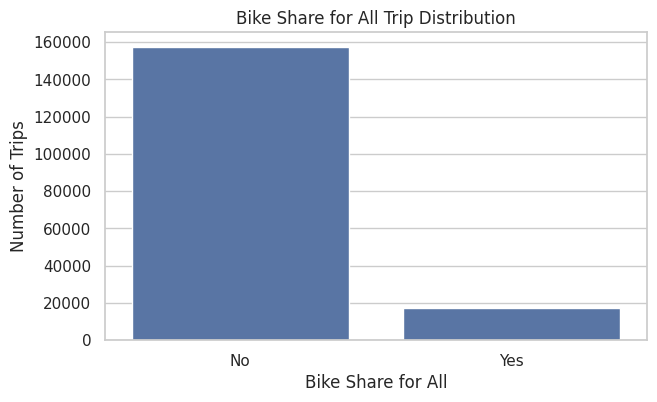

In [ ]:
bike_share_counts = gbf['bike_share_for_all_trip'].value_counts()
bike_share_pct = (gbf['bike_share_for_all_trip'].value_counts(normalize=True) * 100).round(2)
print(pd.DataFrame({'count': bike_share_counts, 'percent': bike_share_pct}))

plt.figure(figsize=(7,4))
sns.countplot(data=gbf, x='bike_share_for_all_trip', order=bike_share_counts.index, color='C0')
plt.title('Bike Share for All Trip Distribution')
plt.xlabel('Bike Share for All')
plt.ylabel('Number of Trips')
plt.show()

**Finding:** Around **90.10%** of trips are marked `No`, while about **9.90%** are marked `Yes`. Bike Share for All users represent a relatively small portion of the trips in this dataset.

## 3) What is the distribution of users' ages?

count    174760.000000
mean         34.125223
std           9.877739
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max          80.000000
Name: member_age, dtype: float64


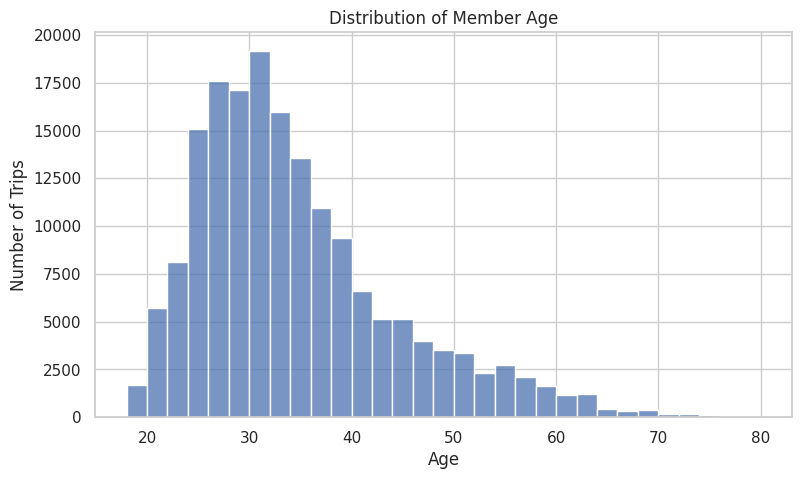

In [ ]:
print(gbf['member_age'].describe())

plt.figure(figsize=(9,5))
bins = np.arange(18, 82, 2)
sns.histplot(data=gbf, x='member_age', bins=bins, color='C0')
plt.title('Distribution of Member Age')
plt.xlabel('Age')
plt.ylabel('Number of Trips')
plt.show()

**Finding:** Rider ages are concentrated in the late 20s and 30s. The **median age is 32**, the **mean is about 34.1**, and the most common age is around 31. The distribution is right-skewed because trip counts decrease among older age groups.

## 4) Do users' ages have outlier values?

Q1=27, Q3=39, IQR=12, IQR upper fence=57


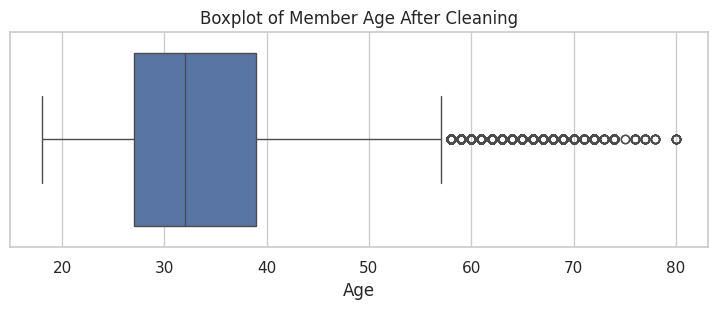

In [ ]:
q1 = gbf['member_age'].quantile(0.25)
q3 = gbf['member_age'].quantile(0.75)
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr
print(f"Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f}, IQR upper fence={upper_iqr:.0f}")

plt.figure(figsize=(9,2.8))
sns.boxplot(data=gbf, x='member_age', color='C0')
plt.title('Boxplot of Member Age After Cleaning')
plt.xlabel('Age')
plt.show()

**Finding:** Before cleaning, the source data contained implausible ages as high as 141, so ages above 80 were removed. After cleaning, the boxplot still marks some older riders (roughly above the IQR upper fence of 57) as **statistical outliers**, but these values are still plausible and were therefore retained.

## 5) What is the distribution of trip duration in minutes?

count    174760.000000
mean         11.738494
std          27.383861
min           1.016667
50%           8.516667
75%          13.150000
90%          19.350000
95%          25.533333
99%          52.947000
max        1409.133333
Name: duration_min, dtype: float64


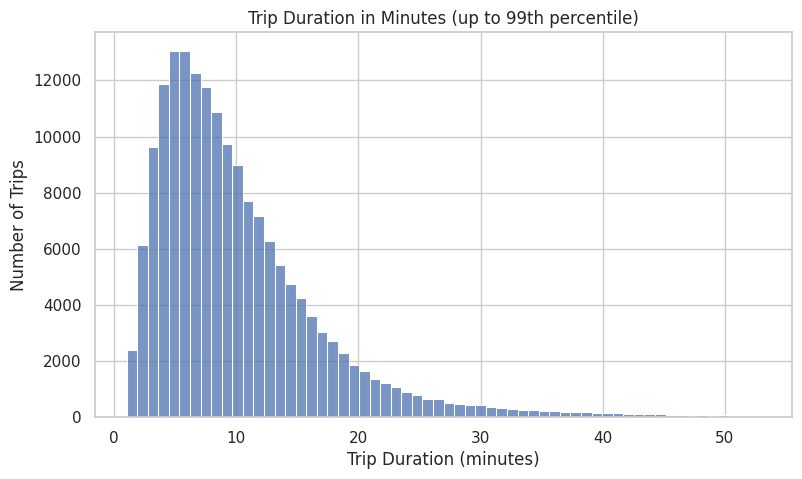

In [ ]:
print(gbf['duration_min'].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

p99_min = gbf['duration_min'].quantile(0.99)
plt.figure(figsize=(9,5))
sns.histplot(gbf.loc[gbf['duration_min'] <= p99_min, 'duration_min'], bins=60, color='C0')
plt.title('Trip Duration in Minutes (up to 99th percentile)')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.show()

**Finding:** Trip duration is strongly right-skewed. The **median trip is about 8.52 minutes**, the mean is about **11.74 minutes**, and **95% of trips are at or below about 25.53 minutes**. A small number of very long trips create the long right tail.

## 6) What is the distribution of member gender?

                count  percent
member_gender                 
Male           130345    74.59
Female          40771    23.33
Other            3644     2.09


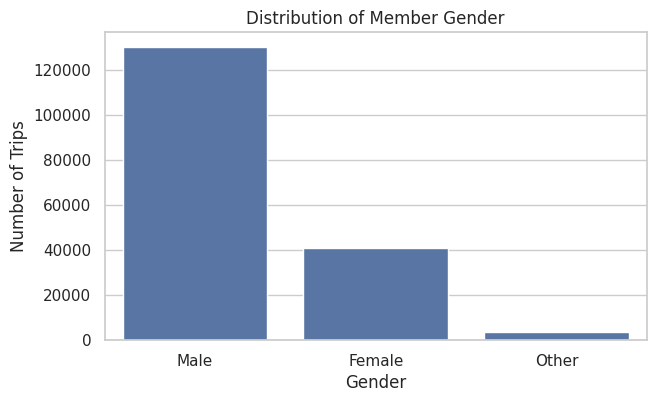

In [ ]:
gender_counts = gbf['member_gender'].value_counts()
gender_pct = (gbf['member_gender'].value_counts(normalize=True) * 100).round(2)
print(pd.DataFrame({'count': gender_counts, 'percent': gender_pct}))

plt.figure(figsize=(7,4))
sns.countplot(data=gbf, x='member_gender', order=gender_counts.index, color='C0')
plt.title('Distribution of Member Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
plt.show()

**Finding:** Male riders account for about **74.59%** of trips, Female riders for about **23.33%**, and `Other` for about **2.09%**. The recorded usage is therefore heavily male-dominated.

## 7) What is the distribution of trip duration in hours?

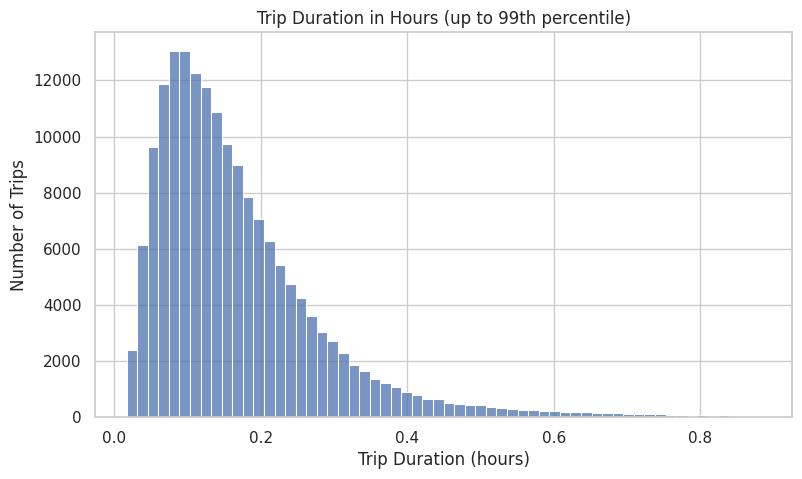

In [ ]:
p99_hour = gbf['duration_hour'].quantile(0.99)
plt.figure(figsize=(9,5))
sns.histplot(gbf.loc[gbf['duration_hour'] <= p99_hour, 'duration_hour'], bins=60, color='C0')
plt.title('Trip Duration in Hours (up to 99th percentile)')
plt.xlabel('Trip Duration (hours)')
plt.ylabel('Number of Trips')
plt.show()

**Finding:** Expressed in hours, the same pattern is clear: most trips are well below half an hour. The long-trip tail is small relative to the full dataset.

### Univariate summary
- Most trips are made by **Subscribers**.
- Most recorded riders are **Male**.
- Most riders are approximately in their **late 20s to late 30s**.
- Typical trips are **short**, with a median of about 8.5 minutes.
- Trip duration is highly right-skewed, so medians and percentile-based views are more representative than the maximum.
- Extreme implausible ages were identified and removed during cleaning; plausible older users were retained.

# Bivariate Exploration

## 8) What is the average trip duration for each user type?

In [ ]:
user_duration = gbf.groupby('user_type', observed=True)['duration_min'].agg(['mean','median','count']).round(2)
user_duration

,mean,median,count
user_type,,,
Customer,21.85,13.00,16557
Subscriber,10.68,8.17,158203


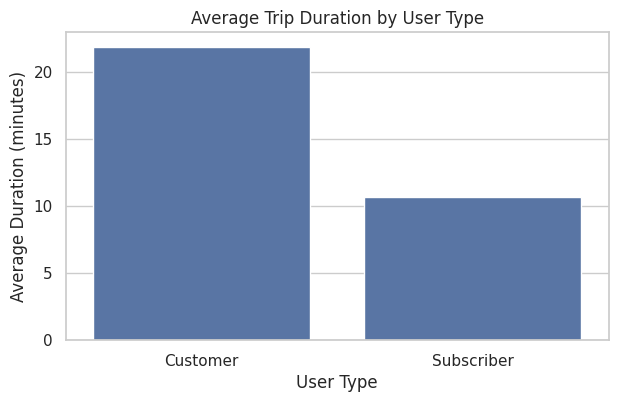

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data=gbf, x='user_type', y='duration_min', estimator=np.mean, errorbar=None, color='C0')
plt.title('Average Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Average Duration (minutes)')
plt.show()

**Finding:** Customers have much longer trips on average (**~21.85 min**) than Subscribers (**~10.68 min**). Their medians also differ: about **13.0 min** for Customers versus **8.17 min** for Subscribers. This suggests different usage patterns between occasional and subscribed riders.

## 9) How long is the trip duration for each gender?

In [ ]:
gender_duration = gbf.groupby('member_gender', observed=True)['duration_min'].agg(['mean','median','count']).round(2)
gender_duration

,mean,median,count
member_gender,,,
Female,12.99,9.47,40771
Male,11.21,8.22,130345
Other,16.63,9.25,3644


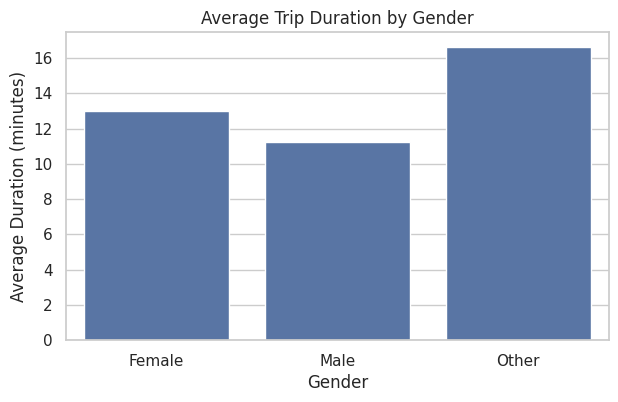

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data=gbf, x='member_gender', y='duration_min', estimator=np.mean, errorbar=None, color='C0')
plt.title('Average Trip Duration by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Duration (minutes)')
plt.show()

**Finding:** Average duration is about **11.21 min for Male**, **12.99 min for Female**, and **16.63 min for Other**. The `Other` group is much smaller, so its mean should be interpreted cautiously.

## 10) How does trip duration vary by user type?

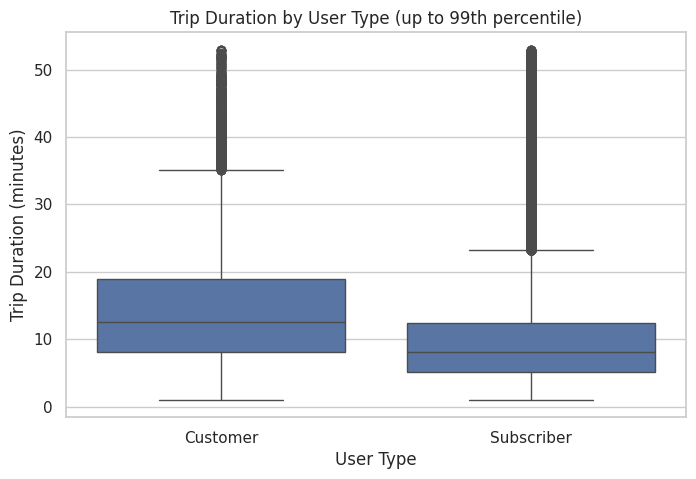

In [ ]:
# Restrict the visualization to the 99th percentile so the central distributions are readable.
p99 = gbf['duration_min'].quantile(0.99)
plot_df = gbf[gbf['duration_min'] <= p99]

plt.figure(figsize=(8,5))
sns.boxplot(data=plot_df, x='user_type', y='duration_min', color='C0')
plt.title('Trip Duration by User Type (up to 99th percentile)')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.show()

**Finding:** Customer trips have a higher median and a wider duration spread than Subscriber trips. The difference is not only caused by a few extreme trips; it appears across the central distribution as well.

## 11) How does age distribution vary by user type?

In [ ]:
age_user = gbf.groupby('user_type', observed=True)['member_age'].agg(['mean','median','count']).round(2)
age_user

,mean,median,count
user_type,,,
Customer,33.61,32.0,16557
Subscriber,34.18,32.0,158203


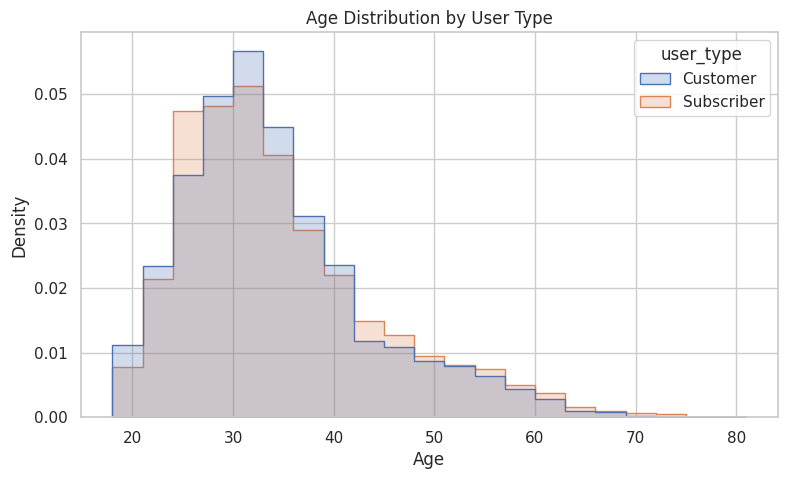

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(data=gbf, x='member_age', hue='user_type', bins=np.arange(18,82,3),
             element='step', stat='density', common_norm=False)
plt.title('Age Distribution by User Type')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

**Finding:** The age profiles of Customers and Subscribers are fairly similar. Their medians are both **32 years**, while Subscribers are only slightly older on average. User type therefore differs much more strongly in **trip duration** than in **age**.

## 12) How does age distribution vary by member gender?

In [ ]:
age_gender = gbf.groupby('member_gender', observed=True)['member_age'].agg(['mean','median','count']).round(2)
age_gender

,mean,median,count
member_gender,,,
Female,33.17,31.0,40771
Male,34.38,32.0,130345
Other,35.85,34.0,3644


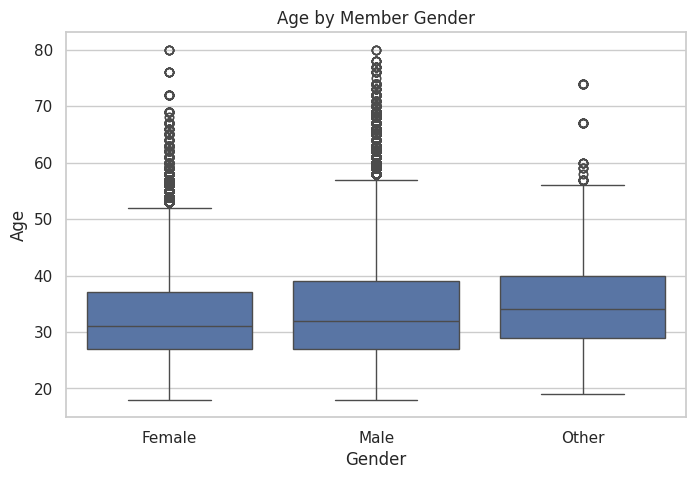

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=gbf, x='member_gender', y='member_age', color='C0')
plt.title('Age by Member Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

**Finding:** Median ages are relatively close across gender groups: approximately **31 for Female**, **32 for Male**, and **34 for Other**. The main difference among gender groups in this dataset is the number of trips rather than a large separation in age.

### Bivariate summary
The strongest behavioral difference observed is between **Customers and Subscribers**: Customers take substantially longer trips. Gender groups also differ in average trip duration, although the `Other` category has far fewer records. Age distributions are comparatively similar across user types and only modestly different across gender groups.

# Multivariate Exploration

## 13) What is the correlation between numeric variables in the dataset?

In [ ]:
# Exclude pure identifier columns from the behavioral interpretation, but keep geographic coordinates.
corr_cols = [
    'duration_sec', 'duration_min', 'duration_hour',
    'member_birth_year', 'member_age',
    'start_station_latitude', 'start_station_longitude',
    'end_station_latitude', 'end_station_longitude'
]
corr_all = gbf[corr_cols].corr()
corr_all.round(3)

,duration_sec,duration_min,duration_hour,member_birth_year,member_age,start_station_latitude,start_station_longitude,end_station_latitude,end_station_longitude
duration_sec,1.000,1.000,1.000,-0.007,0.007,0.012,-0.041,0.013,-0.041
duration_min,1.000,1.000,1.000,-0.007,0.007,0.012,-0.041,0.013,-0.041
duration_hour,1.000,1.000,1.000,-0.007,0.007,0.012,-0.041,0.013,-0.041
member_birth_year,-0.007,-0.007,-0.007,1.000,-1.000,-0.076,0.127,-0.076,0.128
member_age,0.007,0.007,0.007,-1.000,1.000,0.076,-0.127,0.076,-0.128
start_station_latitude,0.012,0.012,0.012,-0.076,0.076,1.000,-0.678,0.990,-0.684
start_station_longitude,-0.041,-0.041,-0.041,0.127,-0.127,-0.678,1.000,-0.683,0.993
end_station_latitude,0.013,0.013,0.013,-0.076,0.076,0.990,-0.683,1.000,-0.685
end_station_longitude,-0.041,-0.041,-0.041,0.128,-0.128,-0.684,0.993,-0.685,1.000


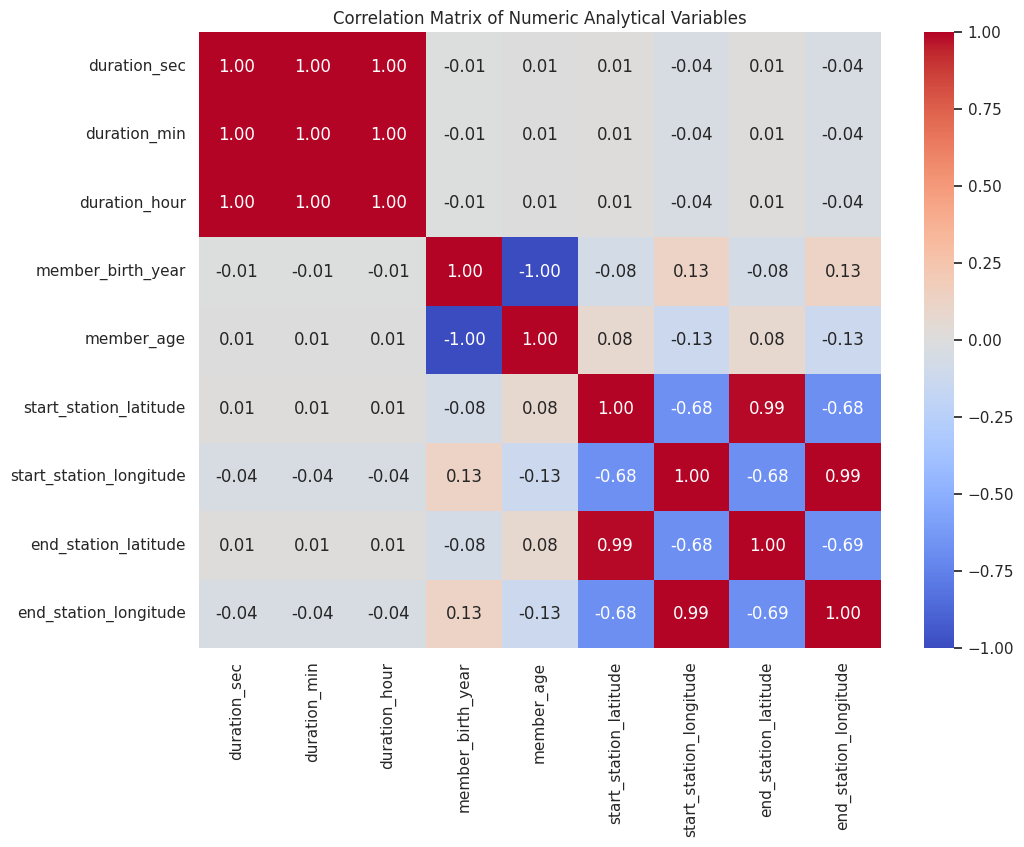

In [ ]:
plt.figure(figsize=(11,8))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Analytical Variables')
plt.show()

**Finding:**
- `duration_sec`, `duration_min`, and `duration_hour` have perfect positive correlation because they are the same quantity expressed in different units.
- `member_birth_year` and `member_age` have perfect negative correlation because age is calculated directly from birth year.
- Age has almost no linear correlation with trip duration.
- Start and end longitudes/latitudes show strong geographic relationships because stations occupy the same Bay Area network. These geographic correlations should not be interpreted as rider behavior.

## 14) What is the relationship between specific numeric variables?

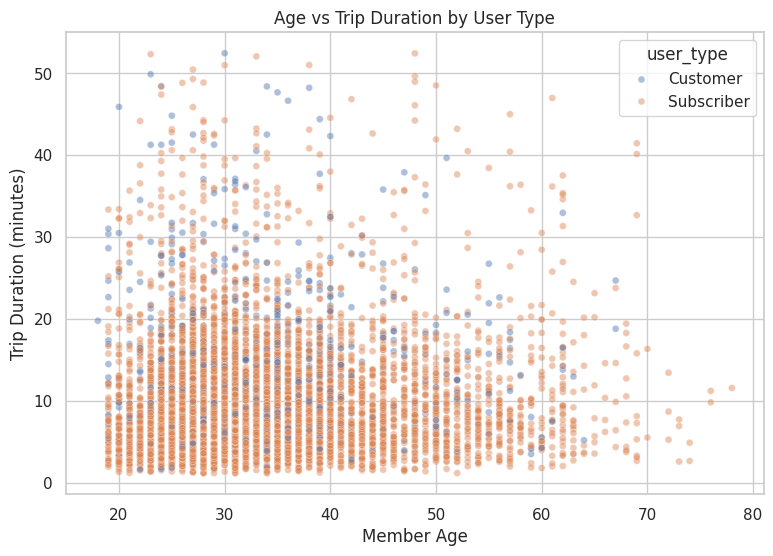

In [ ]:
# Use a sample for readability and exclude the longest 1% of trips in the plot.
plot_limit = gbf['duration_min'].quantile(0.99)
sample_df = gbf[gbf['duration_min'] <= plot_limit].sample(
    n=min(7000, len(gbf)), random_state=42
)

plt.figure(figsize=(9,6))
sns.scatterplot(data=sample_df, x='member_age', y='duration_min',
                hue='user_type', palette='deep', alpha=0.45, s=25)
plt.title('Age vs Trip Duration by User Type')
plt.xlabel('Member Age')
plt.ylabel('Trip Duration (minutes)')
plt.show()

**Finding:** There is no strong linear relationship between age and trip duration. Across most ages, Customer trips tend to extend to higher durations than Subscriber trips, reinforcing the user-type pattern found in the bivariate analysis.

## 15) Correlation among the main statistical variables

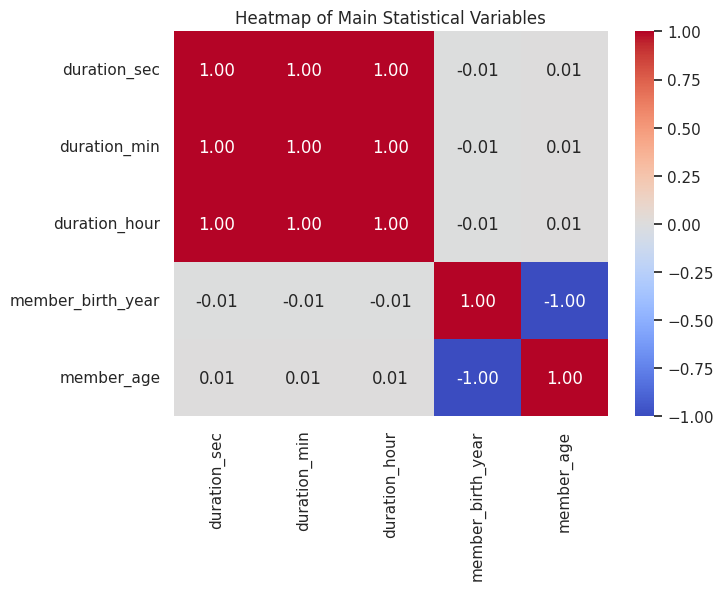

In [ ]:
data_stat = gbf[['duration_sec', 'duration_min', 'duration_hour', 'member_birth_year', 'member_age']]
stat_corr = data_stat.corr()

plt.figure(figsize=(7,5))
sns.heatmap(stat_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Heatmap of Main Statistical Variables')
plt.show()

**Finding:** The heatmap confirms two mathematical relationships: all duration-unit columns correlate at **+1.00**, while birth year and age correlate at **−1.00**. Other age-duration relationships are effectively near zero. For future models, only one duration unit and only one of birth year/age should be retained to avoid redundant features.

# Conclusions

### Key findings
- The cleaned dataset contains **174,760 trips**.
- **Subscribers make 90.53%** of trips; Customers make 9.47%.
- **Male riders make 74.59%** of recorded trips, Female riders 23.33%, and Other riders 2.09%.
- Only **9.90%** of trips are associated with Bike Share for All.
- Riders are concentrated around their late 20s and 30s; the median rider age is **32**.
- Trips are generally short: the median is **8.52 minutes**, and about **95% are no longer than 25.53 minutes**.
- Customers ride considerably longer than Subscribers: approximately **21.85 vs 10.68 minutes on average**.
- Age has very little linear relationship with trip duration.
- Correlation among duration units and between birth year/age is mathematical redundancy, not a new behavioral finding.

### Recommendations
- Because Subscribers form the dominant usage group and usually take short trips, operations should prioritize bike availability and station turnover for frequent short rides.
- Customers take longer trips, suggesting an opportunity to investigate targeted conversion offers or subscription plans for frequent casual users.
- The large gender imbalance may justify further research into barriers to adoption among underrepresented rider groups before designing outreach campaigns.
- Future analyses should use a source file with complete timestamps to study peak hours, weekdays/weekends, and demand patterns over time.

### Limitations
- The provided `start_time` and `end_time` values are not complete timestamps, preventing reliable time-of-day/day-of-week analysis.
- Rows with missing critical demographics/station fields were removed, so the final dataset does not represent those missing records.
- Implausible ages above 80 were removed; age is derived from the recorded birth year and may still contain self-reporting errors.
- The dataset covers only **February 2019**, so the findings should not automatically be generalized to other months or years.
- No information about trip purpose, weather, pricing, or rider satisfaction is available, so the reasons behind observed behavior cannot be confirmed from this dataset alone.